In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Dataset Overview:")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
Dataset shape: (1338, 7)

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
# Data preprocessing
print("\nDataset Information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%     

In [3]:
# Handle categorical variables
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['sex'] = le.fit_transform(df['sex'])  # 0: female, 1: male
df_encoded['smoker'] = le.fit_transform(df['smoker'])  # 0: no, 1: yes
df_encoded['region'] = le.fit_transform(df['region'])

print("\nEncoded dataset sample:")
print(df_encoded.head())


Encoded dataset sample:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


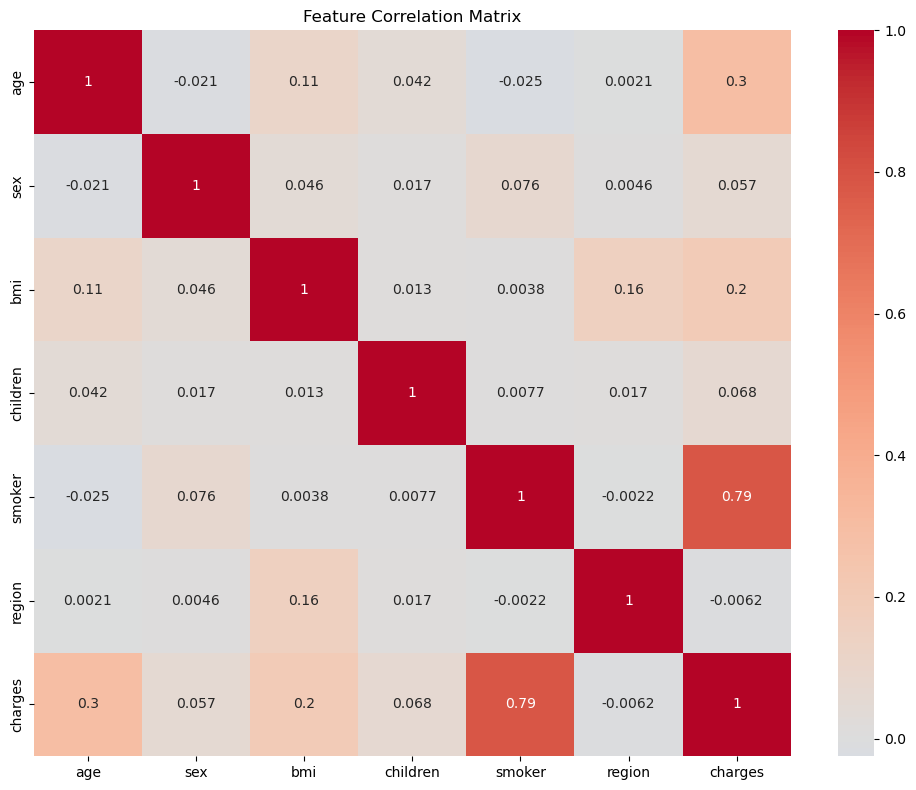


Correlation with charges:
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


In [4]:
# Correlation analysis
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with charges:")
print(correlation_matrix['charges'].sort_values(ascending=False))

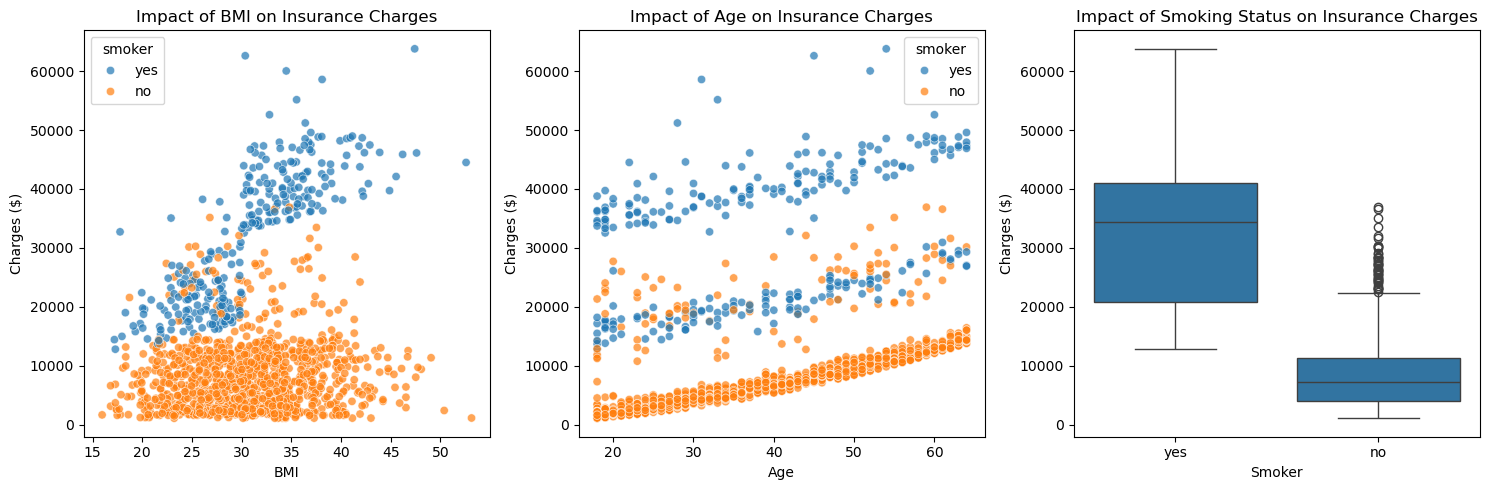

In [5]:
# Visualization 1: Impact of BMI on charges
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('Impact of BMI on Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# Visualization 2: Impact of age on charges
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Impact of Age on Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

# Visualization 3: Impact of smoking status on charges
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Impact of Smoking Status on Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')

plt.tight_layout()
plt.show()

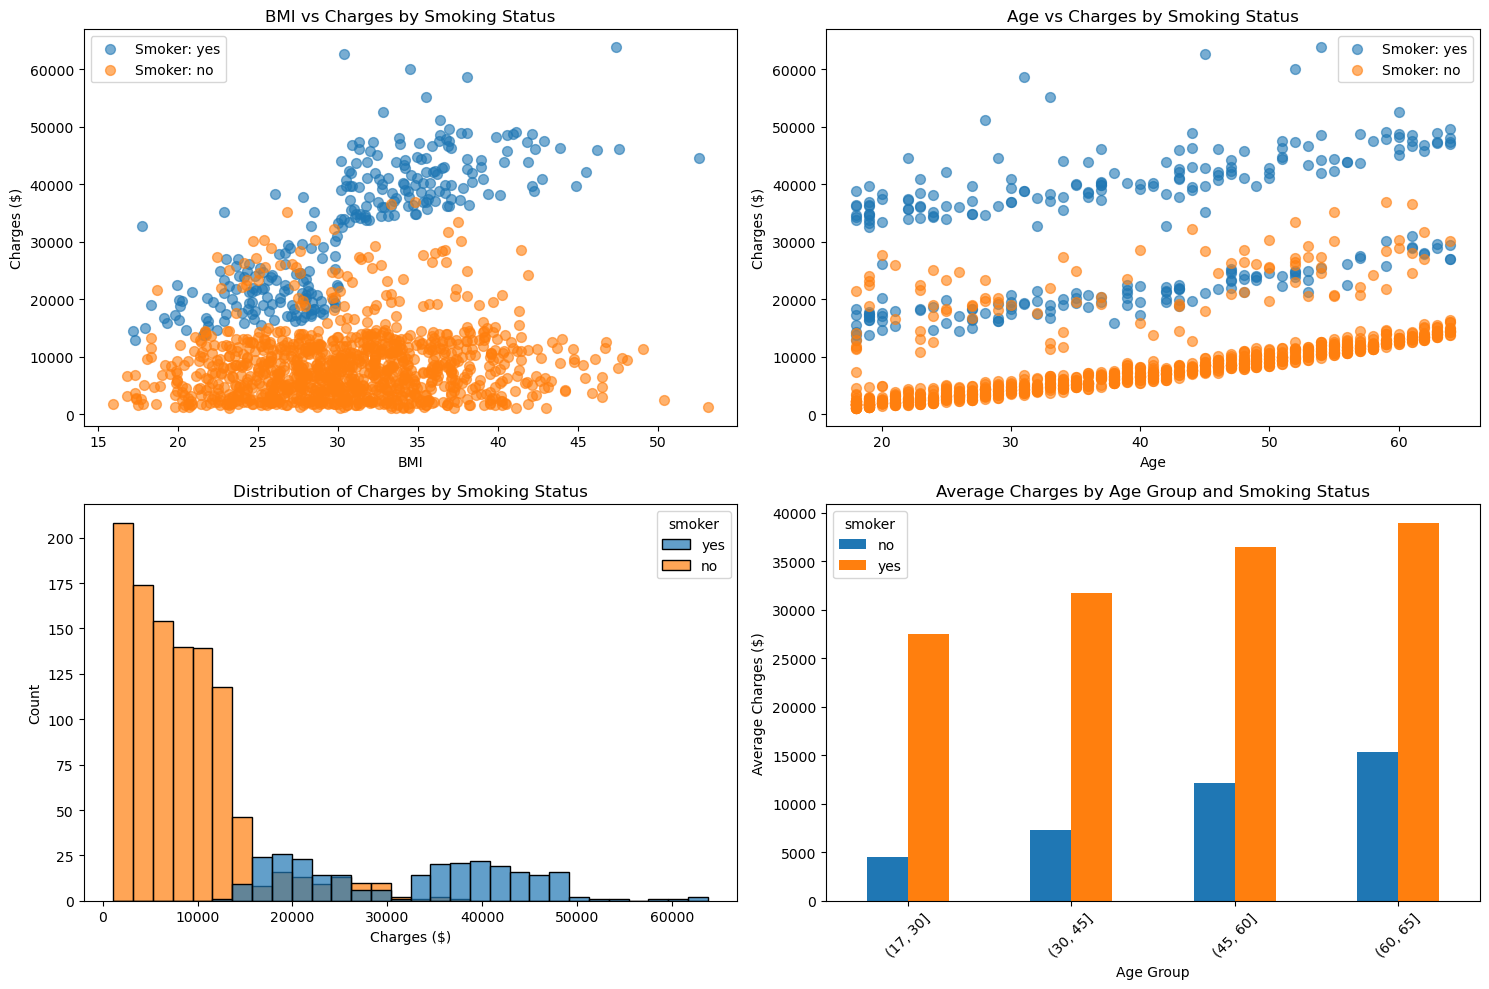

In [6]:
# Additional detailed visualization
plt.figure(figsize=(15, 10))

# BMI vs Charges by smoking status
plt.subplot(2, 2, 1)
for smoker in df['smoker'].unique():
    subset = df[df['smoker'] == smoker]
    plt.scatter(subset['bmi'], subset['charges'], alpha=0.6, 
                label=f'Smoker: {smoker}', s=50)
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.title('BMI vs Charges by Smoking Status')
plt.legend()

# Age vs Charges by smoking status
plt.subplot(2, 2, 2)
for smoker in df['smoker'].unique():
    subset = df[df['smoker'] == smoker]
    plt.scatter(subset['age'], subset['charges'], alpha=0.6, 
                label=f'Smoker: {smoker}', s=50)
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.title('Age vs Charges by Smoking Status')
plt.legend()

# Distribution of charges by smoking status
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='charges', hue='smoker', bins=30, alpha=0.7)
plt.title('Distribution of Charges by Smoking Status')
plt.xlabel('Charges ($)')

# Average charges by age group and smoking status
plt.subplot(2, 2, 4)
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 65])
avg_charges = df.groupby(['age_group', 'smoker'])['charges'].mean().unstack()
avg_charges.plot(kind='bar', ax=plt.gca())
plt.title('Average Charges by Age Group and Smoking Status')
plt.xlabel('Age Group')
plt.ylabel('Average Charges ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Prepare data for modeling
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Model coefficients
feature_names = X.columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nModel Coefficients:")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.2f}")

Training set size: (1070, 6)
Test set size: (268, 6)

Model Coefficients:
    Feature  Coefficient
4    smoker  9557.143383
0       age  3616.108652
2       bmi  2028.308579
3  children   516.662566
5    region  -302.387980
1       sex    -9.392954

Intercept: 13346.09


In [8]:
# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse:.2f}")

# Compare with baseline (mean)
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
baseline_rmse = np.sqrt(mean_squared_error(y_test, [y_train.mean()] * len(y_test)))

print(f"\nBaseline (Mean) MAE: ${baseline_mae:.2f}")
print(f"Baseline (Mean) RMSE: ${baseline_rmse:.2f}")
print(f"Improvement over baseline: {(1 - mae/baseline_mae)*100:.1f}%")

# R-squared score
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)
print(f"\nR-squared - Training: {train_score:.3f}")
print(f"R-squared - Test: {test_score:.3f}")

Model Performance Metrics:
Mean Absolute Error (MAE): $4186.51
Root Mean Square Error (RMSE): $5799.59

Baseline (Mean) MAE: $9593.34
Baseline (Mean) RMSE: $12465.61
Improvement over baseline: 56.4%

R-squared - Training: 0.742
R-squared - Test: 0.783


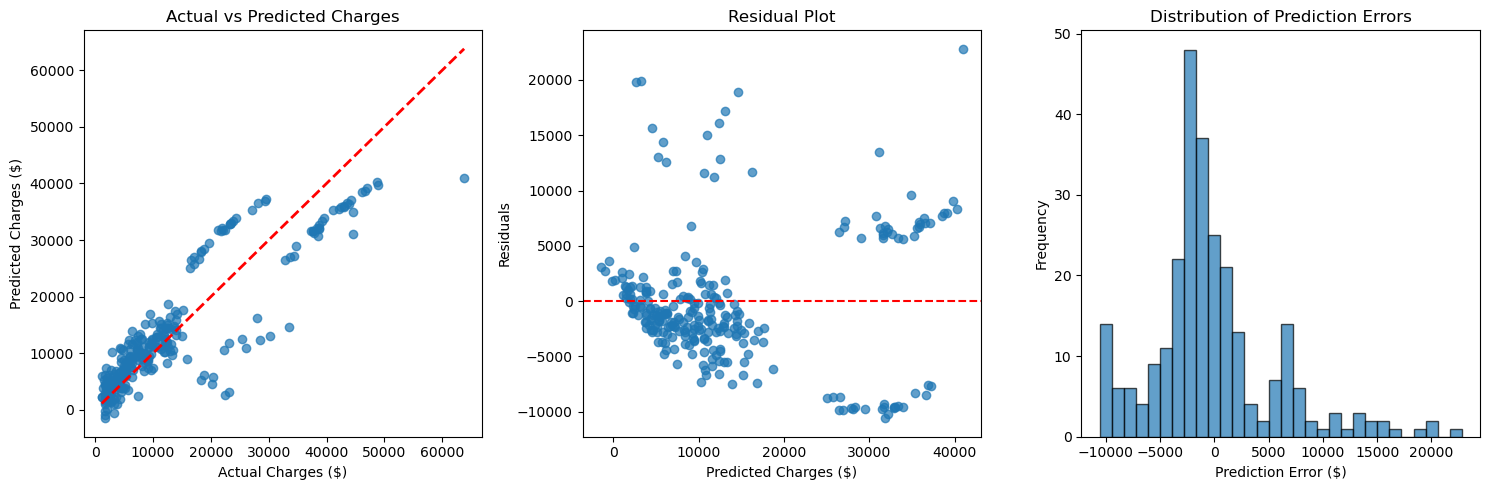

In [9]:
# Visualization of predictions vs actual values
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Charges')

# Residual plot
plt.subplot(1, 3, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Error distribution
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')

plt.tight_layout()
plt.show()

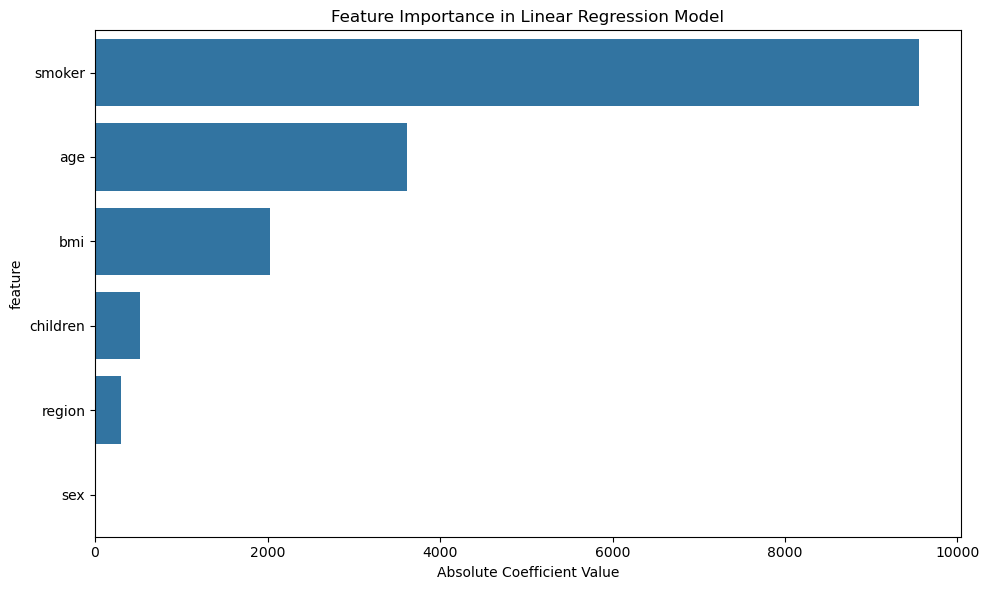


Key Insights:
1. Smoking status has the strongest impact on insurance charges
2. Age is the second most important factor
3. BMI shows moderate correlation with charges
4. Region and sex have relatively smaller impacts


In [10]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': abs(model.coef_)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance in Linear Regression Model')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("1. Smoking status has the strongest impact on insurance charges")
print("2. Age is the second most important factor")
print("3. BMI shows moderate correlation with charges")
print("4. Region and sex have relatively smaller impacts")